In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from wpca import PCA, WPCA, EMPCA
import pandas as pd
from scipy.interpolate import interp1d
from matplotlib.widgets import Slider, Button
from matplotlib.widgets import Button

In [2]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/dps_classified.fits')
model_2comp = left_2comp + right_2comp

In [3]:
incl_df = pd.read_csv('./catalogs/dp_catalog_with_inclination.csv')
dps_df = pd.merge(dps_df, incl_df, on='TARGETID', how='left')

In [4]:
lams = np.empty((dps_df.shape[0], len(desi_wavelength)))
lams = desi_wavelength.copy() / (1 + dps_df['Z'].to_numpy()[:, np.newaxis])

In [5]:
print(len(dps_df))

25807


In [6]:
test_i = np.random.randint(len(dps_df))
lam = lams[test_i]
model = model_2comp[test_i]
crop_region1 = (lam > OII_rest[0]-10) & (lam < OII_rest[1]+10)
crop_region2 = (lam > Hbeta_rest[0]-10) & (lam < Hbeta_rest[0]+10)
crop_region3 = (lam > OIII_rest[1]-20) & (lam < OIII_rest[1]+20)
crop_region4 = (lam > NII_rest[0]-20) & (lam < NII_rest[1]+20)
crop_region5 = (lam > SII_rest[0]-10) & (lam < SII_rest[1]+10)
combine_model = np.concatenate([model[crop_region3], model[crop_region4]])
normalized_model = combine_model / np.max(np.nan_to_num(combine_model, nan=0))

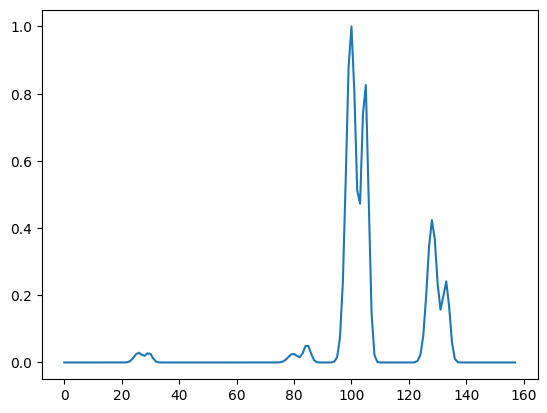

In [7]:
plt.plot(normalized_model)
plt.show()

In [8]:
all_spectra = []
filtered_indices = []
for i in range(len(dps_df)):
    lam = lams[i]
    crop_region1 = (lam > OII_rest[0]-10) & (lam < OII_rest[1]+10)
    crop_region2 = (lam > Hbeta_rest[0]-10) & (lam < Hbeta_rest[0]+10)
    crop_region3 = (lam > OIII_rest[1]-20) & (lam < OIII_rest[1]+20)
    crop_region4 = (lam > NII_rest[0]-20) & (lam < NII_rest[1]+20)
    crop_region5 = (lam > SII_rest[0]-10) & (lam < SII_rest[1]+10)
    
    model = model_2comp[i]
    combine_model = np.concatenate([model[crop_region3], model[crop_region4]])

    interpolator = interp1d(np.arange(len(combine_model)), combine_model, bounds_error=False, fill_value='extrapolate')
    combine_model = interpolator(np.linspace(0, len(combine_model)-1, 500))

    normalized_model = combine_model / np.max(np.nan_to_num(combine_model, nan=0))

    if np.all(np.isfinite(normalized_model)):
        all_spectra.append(normalized_model)
        filtered_indices.append(i)


In [9]:
filtered_dps = dps_df.iloc[filtered_indices]
filtered_dps.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count,BPT_class,incl
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.451893,-78.319199,50.218773,30.572901,...,8,3,6,0,1,7,9,2,512,NaN
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,112.483803,-62.245144,42.930370,68.479820,...,9,8,2,0,1,4,6,1,512,NaN
2,39627739380058467,177.097977,-1.888290,0.123931,10.402426,1.031611,88.860611,-27.739218,29.598230,52.082478,...,9,8,7,0,1,2,4,3,512,NaN
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,80.845169,-86.188843,52.286289,59.410812,...,9,8,4,0,1,2,5,2,512,NaN
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,88.226196,-73.512642,38.063850,50.911797,...,9,8,7,0,1,4,6,5,257,NaN


In [10]:
print(len(filtered_dps))

25807


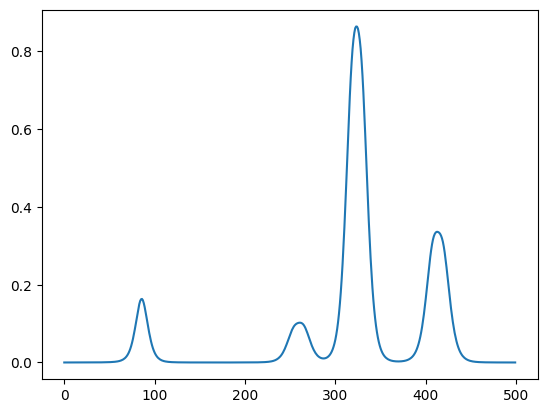

In [11]:
plt.plot(np.mean(all_spectra, axis=0))
plt.show()

In [12]:
n_comp = 15
pca = WPCA(n_components=n_comp).fit(all_spectra, weights=None)
coeff = pca.fit_transform(all_spectra)[:, :n_comp]


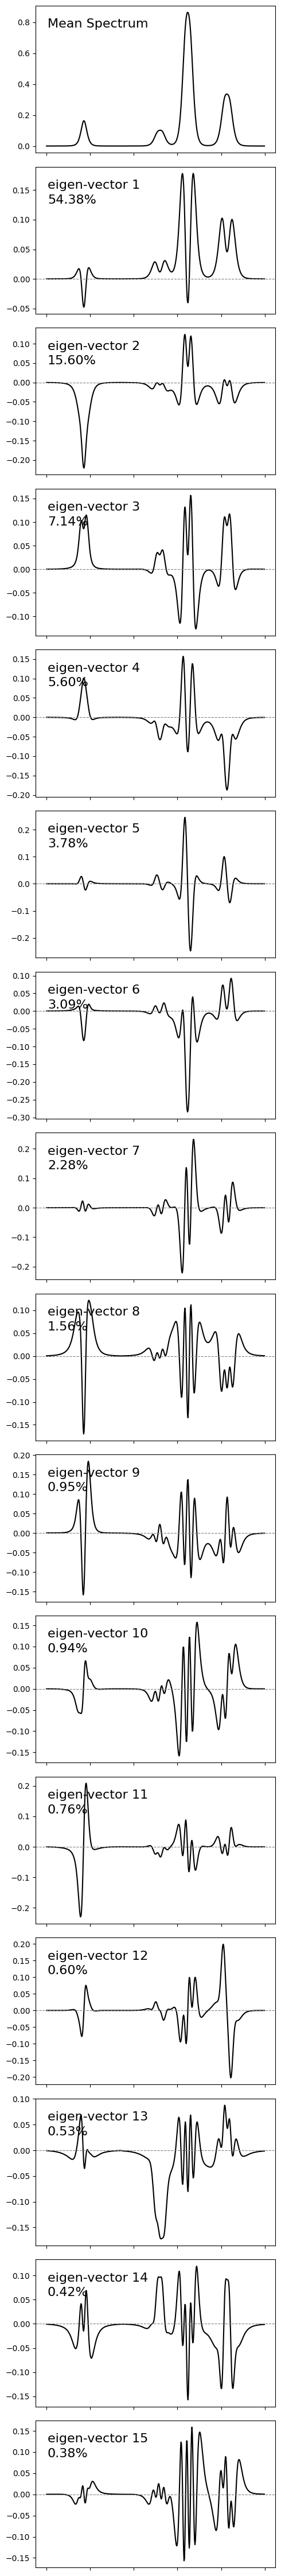

In [13]:

fig, ax = plt.subplots(n_comp+1, 1, figsize=(5, 3*n_comp), sharex=True)
plt.subplots_adjust(hspace=-0.5)

ax[0].plot(pca.mean_, c='black')
ax[0].text(0.05, 0.85, 'Mean Spectrum', transform=ax[0].transAxes, fontsize=16)
ax[0].set_xticklabels([])

for i in range(n_comp):
    ax[i+1].plot(pca.components_[i], c='black')
    ax[i+1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax[i+1].text(0.05, 0.75, f'{100*pca.explained_variance_ratio_[i]:.2f}%', transform=ax[i+1].transAxes, fontsize=16)
    ax[i+1].text(0.05, 0.85, f'eigen-vector {i+1}', transform=ax[i+1].transAxes, fontsize=16)
    if i != n_comp - 1:
        ax[i+1].set_xticklabels([])
plt.tight_layout()
plt.show()


In [14]:

for i in range(6):
    for j in range(6):
        if (i != j) and (i < j):
            plt.figure(figsize=(6, 6))
            plt.scatter(coeff[:, i], coeff[:, j], s=1, alpha=0.5)
            plt.xlabel(f'Coefficient {i+1}')
            plt.ylabel(f'Coefficient {j+1}')
            plt.title('WPCA Coefficient Scatter Plot')
            plt.grid(True)
            plt.axis('equal')
            plt.savefig(f'./figures/wpca_halpha_coeff_scatter_{i+1}_vs_{j+1}.png')
            plt.close('all')

In [15]:
test_i = np.random.randint(len(dps_df))
test_lam = lams[test_i]
test_model = model_2comp[test_i]
crop_region1 = (test_lam > OII_rest[0]-10) & (test_lam < OII_rest[1]+10)
crop_region2 = (test_lam > Hbeta_rest[0]-10) & (test_lam < Hbeta_rest[0]+10)
crop_region3 = (test_lam > OIII_rest[1]-20) & (test_lam < OIII_rest[1]+20)
crop_region4 = (test_lam > NII_rest[0]-20) & (test_lam < NII_rest[1]+20)
crop_region5 = (test_lam > SII_rest[0]-10) & (test_lam < SII_rest[1]+10)
test_combine_model = np.concatenate([test_model[crop_region3], test_model[crop_region4]])
test_normalized_model = test_combine_model / np.max(np.nan_to_num(test_combine_model, nan=0))

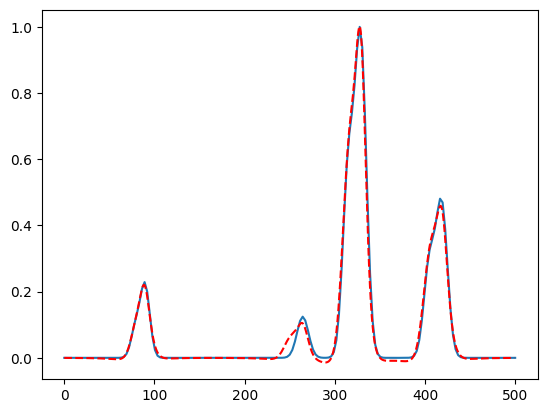

In [16]:
plt.plot(np.linspace(0, 500, len(test_normalized_model)), test_normalized_model)
reconstructed_model = pca.mean_ + np.dot(coeff[test_i, :], pca.components_[:n_comp])
plt.plot(reconstructed_model, c='red', linestyle='--')
plt.show()

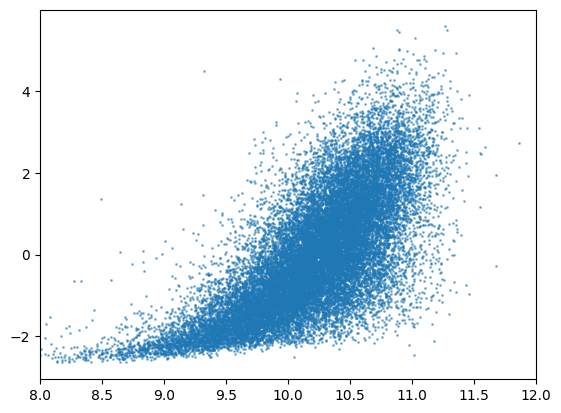

In [17]:
plt.scatter(filtered_dps['LOGM'], coeff[:, 0], s=1, alpha=0.5)
plt.xlim(left=8, right=12)
plt.show()

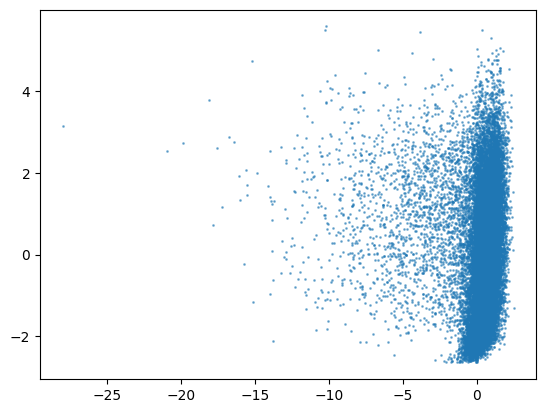

In [18]:
plt.scatter(filtered_dps['LOGSFR'], coeff[:, 0], s=1, alpha=0.5)
# plt.xlim(left=8, right=12)
plt.show()

In [20]:
classification_map_2comp = {
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}
filtered_dps['BPT_class_str'] = filtered_dps['BPT_class'].map(classification_map_2comp)

In [29]:

for i in range(6):
    for j in range(6):
        if (i != j) and (i < j):
            plt.figure(figsize=(6, 6))
            plt.scatter(coeff[filtered_dps['BPT_class_str'] != 'unclassified', i], coeff[filtered_dps['BPT_class_str'] != 'unclassified', j], s=1, alpha=0.5, color='gray')
            plt.scatter(coeff[filtered_dps['BPT_class_str'] == 'SF+uncertain', i], coeff[filtered_dps['BPT_class_str'] == 'SF+uncertain', j], s=1, alpha=0.5, color='blue')
            plt.xlabel(f'Coefficient {i+1}')
            plt.ylabel(f'Coefficient {j+1}')
            plt.title('WPCA Coefficient Scatter Plot')
            plt.grid(True)
            plt.axis('equal')
            plt.savefig(f'./figures/wpca_halpha_coeff_scatter_{i+1}_vs_{j+1}.png')
            plt.close('all')

In [35]:

for i in range(6):
    plt.figure(figsize=(6, 6))
    plt.scatter(filtered_dps[filtered_dps['BPT_class_str'] != 'unclassified']['incl'], coeff[filtered_dps['BPT_class_str'] != 'unclassified', i], s=1, alpha=0.5)
    plt.ylabel(f'Coefficient {i+1}')
    plt.xlabel(f'Inclination')
    plt.xlim(left=0, right=90)
    plt.title('WPCA Coefficient Scatter Plot')
    plt.grid(True)
    # plt.axis('equal')
    plt.savefig(f'./figures/wpca_halpha_coeff_scatter_{i+1}_vs_inclination.png')
    plt.close('all')